# Índice de Caminabilidad — Barrio Obrero
**ITT Cali Inteligente · Equipo de Gobierno de Datos**

Este notebook calcula las métricas de caminabilidad para el área del
**Barrio Obrero** (polígono único de barrio), usando la red peatonal de OpenStreetMap.

**Sistema de referencia:** WGS84 (EPSG:4326) para toda la información geoespacial.
Se usa EPSG:3116 (Colombia) únicamente para cálculos de área y distancia.

**Datos:** `data/Geojson_Barrio_Obrero/`

**Instrucciones:**
1. Ejecutar las celdas en orden
2. Los datos se cargan automáticamente
3. Los resultados y mapas se generan automáticamente

## Celda 1 — Instalación de dependencias

In [42]:
import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for p in ['osmnx', 'geopandas', 'matplotlib', 'pandas', 'numpy', 'folium', 'seaborn', 'scipy']:
    check_pkg(p)
print('Dependencias verificadas')

Dependencias verificadas


## Celda 2 — Importaciones y configuración

In [43]:
import os, re, json, warnings, datetime, logging
from pathlib import Path
import pandas as pd
import numpy as np
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import seaborn as sns
import folium
warnings.filterwarnings('ignore')
logging.getLogger('pyogrio').setLevel(logging.ERROR)

# Sistema de referencia
CRS_WGS84 = 'EPSG:4326'      # Sistema de trabajo (geográfico)
CRS_COLOMBIA = 'EPSG:3116'    # Solo para cálculos de área/distancia (proyectado)

plt.rcParams.update({
    'figure.facecolor': '#F4F6F9',
    'axes.facecolor': 'white',
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3
})
print(f'Sistema de referencia de trabajo: {CRS_WGS84}')
print(f'Sistema proyectado para cálculos: {CRS_COLOMBIA}')
print('Configuración lista')

Sistema de referencia de trabajo: EPSG:4326
Sistema proyectado para cálculos: EPSG:3116
Configuración lista


## Celda 3 — Parámetros, rutas y detección de entorno

In [44]:
# Repositorio del proyecto
REPO_URL = 'https://github.com/j0rg3c45/indice-caminabilidad-roosevelt.git'
REPO_NAME = 'indice-caminabilidad-roosevelt'

# Detectar entorno: Colab o local
if os.path.exists('/content'):
    import subprocess as _sp
    os.chdir('/content')
    _sp.getoutput(f'rm -rf {REPO_NAME}')
    print(_sp.getoutput(f'git clone {REPO_URL}'))
    PROJECT_ROOT = Path(f'/content/{REPO_NAME}')
else:
    PROJECT_ROOT = Path(os.getcwd()).parent

# Rutas relativas al proyecto
DATA_DIR = PROJECT_ROOT / 'data' / 'Geojson_Barrio_Obrero'
EVENTOS_DIR = DATA_DIR / 'nueva_data' / 'geojson_filtrado_poligono_Barrio_Obrero'
IMG_DIR = PROJECT_ROOT / 'outputs' / 'figures'
RESULTS_DIR = PROJECT_ROOT / 'outputs' / 'results'

IMG_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Búsqueda flexible de archivos GeoJSON
def find_file(base_dir, pattern):
    regex = re.compile(pattern, re.IGNORECASE)
    for root, _dirs, files in os.walk(base_dir):
        for f in files:
            if regex.search(f) and f.lower().endswith('.geojson'):
                return os.path.join(root, f)
    return None

# Rutas a los archivos de datos
PATHS = {
    'poligono':     find_file(DATA_DIR, r'Geojson_Barrio_Obrero\.geojson'),
    'comparendos':  find_file(EVENTOS_DIR, r'comparendos'),
    'homicidios':   find_file(EVENTOS_DIR, r'homicidios'),
    'hurtos':       find_file(EVENTOS_DIR, r'hurtos'),
    'vif':          find_file(EVENTOS_DIR, r'violencia_intrafamiliar'),
    'censo_arboreo': find_file(EVENTOS_DIR, r'CENSO_ARBOREO'),
}

ZONA_NOMBRE = 'Barrio Obrero — Cali'

print(f'DATA_DIR: {DATA_DIR}')
print(f'IMG_DIR:  {IMG_DIR}')
print(f'RESULTS_DIR: {RESULTS_DIR}')
print()
print('Archivos encontrados:')
for nombre, ruta in PATHS.items():
    ok = ruta is not None and os.path.exists(ruta)
    estado = chr(9989) if ok else chr(10060)
    print(f'  {estado}  {nombre:15s}: {Path(ruta).name if ruta else "NO ENCONTRADO"}')

Cloning into 'indice-caminabilidad-roosevelt'...
Updating files:  13% (30/223)
Updating files:  14% (32/223)
Updating files:  15% (34/223)
Updating files:  16% (36/223)
Updating files:  17% (38/223)
Updating files:  18% (41/223)
Updating files:  19% (43/223)
Updating files:  20% (45/223)
Updating files:  21% (47/223)
Updating files:  22% (50/223)
Updating files:  23% (52/223)
Updating files:  24% (54/223)
Updating files:  25% (56/223)
Updating files:  26% (58/223)
Updating files:  27% (61/223)
Updating files:  28% (63/223)
Updating files:  29% (65/223)
Updating files:  30% (67/223)
Updating files:  31% (70/223)
Updating files:  32% (72/223)
Updating files:  33% (74/223)
Updating files:  34% (76/223)
Updating files:  35% (79/223)
Updating files:  36% (81/223)
Updating files:  37% (83/223)
Updating files:  38% (85/223)
Updating files:  39% (87/223)
Updating files:  40% (90/223)
Updating files:  41% (92/223)
Updating files:  42% (94/223)
Updating files:  43% (96/223)
Updating files:  44% 

## Celda 4 — Cargar polígono y asegurar WGS84

In [45]:
# Cargar polígono del barrio DIRECTAMENTE desde el ZIP versionado
# El ZIP vive en data/Geojson_Barrio_Obrero/Geojson_Barrio_Obrero.zip y contiene
# Geojson_Barrio_Obrero.geojson. Se lee con el prefijo zip:// (geopandas/fiona),
# sin necesidad de descomprimir la carpeta (útil en Colab).
ZIP_POLIGONO = DATA_DIR / 'Geojson_Barrio_Obrero.zip'
GEOJSON_EN_ZIP = 'Geojson_Barrio_Obrero.geojson'

if ZIP_POLIGONO.exists():
    ruta_poligono = f'zip://{ZIP_POLIGONO.as_posix()}!{GEOJSON_EN_ZIP}'
    print(f'Cargando polígono desde ZIP: {ZIP_POLIGONO.name}')
else:
    # Respaldo: usar el .geojson descomprimido si el ZIP no está disponible
    ruta_poligono = PATHS['poligono']
    print(f'ZIP no encontrado, usando GeoJSON descomprimido: {ruta_poligono}')

gdf_poligono = gpd.read_file(ruta_poligono)

# Asegurar que el polígono esté en WGS84
if gdf_poligono.crs is None:
    print('AVISO: GeoJSON sin CRS definido, asignando WGS84')
    gdf_poligono = gdf_poligono.set_crs(CRS_WGS84)
elif gdf_poligono.crs.to_epsg() != 4326:
    print(f'Reproyectando polígono de {gdf_poligono.crs} a WGS84...')
    gdf_poligono = gdf_poligono.to_crs(CRS_WGS84)

# Polígono en WGS84 para OSMnx y visualización
polygon_wgs84 = gdf_poligono.geometry.iloc[0]

# Proyectar a EPSG:3116 SOLO para cálculos de área/distancia
gdf_proyectado = gdf_poligono.to_crs(CRS_COLOMBIA)
area_m2 = gdf_proyectado.geometry.area.iloc[0]
area_km2 = area_m2 / 1_000_000

print(f'\n=== ÁREA DE ESTUDIO ===')
print(f'  Zona: {ZONA_NOMBRE}')
print(f'  CRS de trabajo: {gdf_poligono.crs}')
print(f'  CRS para cálculos: {CRS_COLOMBIA}')
print(f'  Área: {area_m2:,.0f} m² ({area_m2/10000:.2f} ha)')
print(f'  Unidad de análisis: polígono único de barrio')

ZIP no encontrado, usando GeoJSON descomprimido: None


DataSourceError: None: No such file or directory

## Celda 5 — Descargar red peatonal desde OpenStreetMap

In [ ]:
# OSMnx requiere el polígono en WGS84 (EPSG:4326)
print(f'Descargando red peatonal (polígono en {CRS_WGS84})...')
G = ox.graph_from_polygon(polygon_wgs84, network_type='walk', simplify=False)
print(f'Red descargada: {len(G.nodes)} nodos, {len(G.edges)} segmentos')
print(f'CRS del grafo: EPSG:4326 (WGS84)')

Descargando red peatonal (polígono en EPSG:4326)...


Red descargada: 233 nodos, 648 segmentos
CRS del grafo: EPSG:4326 (WGS84)


## Celda 6 — Calcular métricas de caminabilidad

In [ ]:
# Calcular estadísticas (área en m² para densidades correctas)
stats = ox.basic_stats(G, area=area_m2)

# Exportar red peatonal como GeoJSON en la carpeta de datos de la zona de estudio
gdf_nodos, gdf_aristas = ox.graph_to_gdfs(G)
red_peatonal_path = DATA_DIR / 'red_peatonal_osm_barrio_obrero.geojson'
gdf_aristas.to_crs(CRS_WGS84).to_file(red_peatonal_path, driver='GeoJSON')
print(f'Red peatonal guardada en zona de estudio: {red_peatonal_path}')

longitud_total_km = stats['edge_length_total'] / 1000
densidad_km_km2 = longitud_total_km / area_km2

metricas_caminabilidad = {
    'Intersecciones peatonales': stats['intersection_count'],
    'Longitud red peatonal (km)': round(longitud_total_km, 2),
    'Longitud promedio segmento (m)': round(stats['edge_length_avg'], 1),
    'Densidad calle (km/km²)': round(densidad_km_km2, 2),
    'Nodos OSM': len(G.nodes),
    'Segmentos OSM': len(G.edges),
}

print('=== MÉTRICAS DE CAMINABILIDAD — LÍNEA BASE ===')
print(f'  Fecha: {datetime.date.today().isoformat()}')
print(f'  CRS análisis: {CRS_WGS84} | Cálculos métricos: {CRS_COLOMBIA}')
print()
for k, v in metricas_caminabilidad.items():
    print(f'  {k}: {v}')

Red peatonal guardada en zona de estudio: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\data\Geojson_Barrio_Obrero\red_peatonal_osm_barrio_obrero.geojson
=== MÉTRICAS DE CAMINABILIDAD — LÍNEA BASE ===
  Fecha: 2026-09-18
  CRS análisis: EPSG:4326 | Cálculos métricos: EPSG:3116

  Intersecciones peatonales: 233
  Longitud red peatonal (km): 26.93
  Longitud promedio segmento (m): 41.6
  Densidad calle (km/km²): 71.38
  Nodos OSM: 233
  Segmentos OSM: 648


## Celda 7 — Cargar datos geoespaciales complementarios (WGS84)

In [ ]:
# Cargar todos los datasets y asegurar WGS84
datasets = {}
print('=== CARGA DE DATASETS (normalizados a WGS84) ===')
print()
for nombre, ruta in PATHS.items():
    if ruta and os.path.exists(ruta) and nombre != 'poligono':
        try:
            gdf = gpd.read_file(ruta)
            # Asegurar WGS84
            if gdf.crs is None:
                gdf = gdf.set_crs(CRS_WGS84)
            elif gdf.crs.to_epsg() != 4326:
                gdf = gdf.to_crs(CRS_WGS84)
            datasets[nombre] = gdf
            print(f'  {chr(9989)} {nombre:15s}: {len(gdf):>5} registros | CRS: {gdf.crs.to_epsg()}')
        except Exception as e:
            print(f'  {chr(10060)} {nombre:15s}: Error - {e}')

print(f'\nTotal datasets cargados: {len(datasets)}')
print(f'Todos en CRS: {CRS_WGS84}')

=== CARGA DE DATASETS (normalizados a WGS84) ===



  ✅ comparendos    :  3741 registros | CRS: 4326
  ✅ homicidios     :    27 registros | CRS: 4326
  ✅ hurtos         :   663 registros | CRS: 4326
  ✅ vif            :    82 registros | CRS: 4326
  ✅ censo_arboreo  :   874 registros | CRS: 4326

Total datasets cargados: 5
Todos en CRS: EPSG:4326


## Celda 8 — Mapa estático de la red peatonal

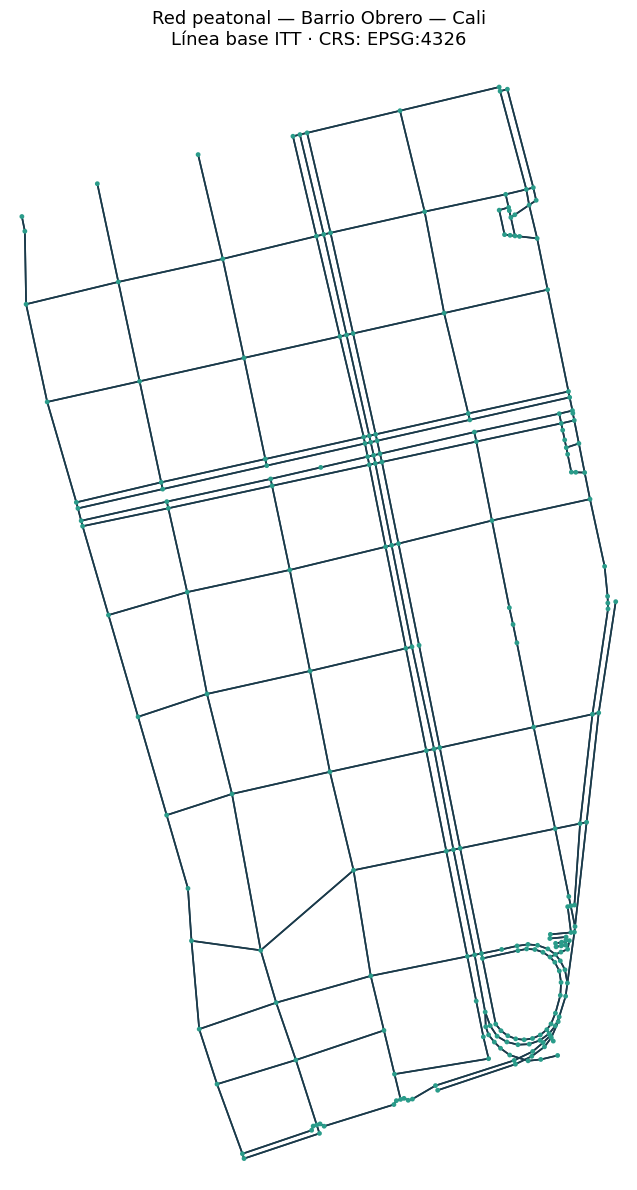

Mapa guardado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\barrio_obrero_red_peatonal_linea_base.png


In [ ]:
fig, ax = ox.plot_graph(
    G,
    node_size=12,
    edge_linewidth=1.2,
    bgcolor='white',
    node_color='#2A9C8A',
    edge_color='#1A3A4A',
    figsize=(12, 12),
    show=False,
    close=False
)
ax.set_title(
    f'Red peatonal — {ZONA_NOMBRE}\nLínea base ITT · CRS: {CRS_WGS84}',
    fontsize=13, pad=15
)
plt.tight_layout()
plt.savefig(IMG_DIR / 'barrio_obrero_red_peatonal_linea_base.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mapa guardado: {IMG_DIR / "barrio_obrero_red_peatonal_linea_base.png"}')

## Celda 9 — Mapa interactivo con capas (WGS84)

In [ ]:
# Mapa interactivo — todo en WGS84
from folium.plugins import HeatMap
centroid = polygon_wgs84.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=16, tiles=None)
# Capas base
folium.TileLayer('CartoDB positron', name='CartoDB Claro').add_to(m)
folium.TileLayer('OpenStreetMap', name='OpenStreetMap').add_to(m)
folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Esri', name='Esri Satélite', overlay=False
).add_to(m)
# Google tiles
google_streets = 'http://{s}.google.com/vt/lyrs=m&x={x}&y={y}&z={z}'
google_satellite = 'http://{s}.google.com/vt/lyrs=s&x={x}&y={y}&z={z}'
folium.TileLayer(
    tiles=google_streets,
    attr='Google', name='Google Streets',
    subdomains=['mt0', 'mt1', 'mt2', 'mt3'], overlay=False
).add_to(m)
folium.TileLayer(
    tiles=google_satellite,
    attr='Google', name='Google Satélite',
    subdomains=['mt0', 'mt1', 'mt2', 'mt3'], overlay=False
).add_to(m)
# Polígono del barrio (ya en WGS84)
folium.GeoJson(
    gdf_poligono.__geo_interface__,
    name='Polígono Barrio Obrero',
    style_function=lambda x: {'color': '#1B4F8A', 'fillColor': '#2E7D32',
                              'fillOpacity': 0.1, 'weight': 2}
).add_to(m)
# Tramo del barrio (eje/corredor) — capa de línea destacada
tramo_path = DATA_DIR / 'tramo_Barrio_obrero.geojson'
if tramo_path.exists():
    gdf_tramo = gpd.read_file(tramo_path)
    if gdf_tramo.crs is None:
        gdf_tramo = gdf_tramo.set_crs(CRS_WGS84)
    elif gdf_tramo.crs.to_epsg() != 4326:
        gdf_tramo = gdf_tramo.to_crs(CRS_WGS84)
    folium.GeoJson(
        gdf_tramo.__geo_interface__,
        name='Tramo Barrio Obrero (eje)',
        style_function=lambda x: {'color': '#E53935', 'weight': 4, 'opacity': 0.9}
    ).add_to(m)
    print(f'Tramo agregado: {tramo_path.name}')
else:
    print(f'Tramo no encontrado: {tramo_path}')
# Red peatonal OSM (descargada en Celda 5)
gdf_edges = ox.graph_to_gdfs(G, nodes=False, edges=True)
gdf_edges_wgs84 = gdf_edges.to_crs(CRS_WGS84) if gdf_edges.crs.to_epsg() != 4326 else gdf_edges
folium.GeoJson(
    gdf_edges_wgs84[['geometry']].__geo_interface__,
    name='Red peatonal OSM (líneas)',
    style_function=lambda x: {'color': '#2A9C8A', 'weight': 2, 'opacity': 0.7}
).add_to(m)
# Nodos del grafo (intersecciones)
gdf_nodes = ox.graph_to_gdfs(G, nodes=True, edges=False)
gdf_nodes_wgs84 = gdf_nodes.to_crs(CRS_WGS84) if gdf_nodes.crs.to_epsg() != 4326 else gdf_nodes
fg_nodos = folium.FeatureGroup(name='Nodos (intersecciones)', show=True)
for _, row in gdf_nodes_wgs84.iterrows():
    folium.CircleMarker(
        location=[row.geometry.y, row.geometry.x],
        radius=3, color='#E53935', fill=True, fill_opacity=0.9, weight=1
    ).add_to(fg_nodos)
fg_nodos.add_to(m)
# Mapa de calor de intersecciones peatonales (activable desde el control de capas)
if 'street_count' in gdf_nodes_wgs84.columns:
    intersecciones_hm = gdf_nodes_wgs84[gdf_nodes_wgs84['street_count'] > 2]
else:
    intersecciones_hm = gdf_nodes_wgs84
heat_data = [[pt.y, pt.x] for pt in intersecciones_hm.geometry]
fg_heat = folium.FeatureGroup(name='Mapa de calor — intersecciones', show=False)
HeatMap(heat_data, radius=18, blur=15, min_opacity=0.3).add_to(fg_heat)
fg_heat.add_to(m)
# Colores por capa
COLORES = {
    'comparendos': 'orange', 'homicidios': 'darkred',
    'hurtos': 'purple', 'vif': 'darkpurple', 'censo_arboreo': 'green',
}
# Agregar capas de eventos (todas en WGS84)
for nombre, gdf in datasets.items():
    fg = folium.FeatureGroup(name=nombre.replace('_', ' ').capitalize(), show=False)
    color = COLORES.get(nombre, 'gray')
    for _, row in gdf.iterrows():
        geom = row.geometry
        if geom is None:
            continue
        if geom.geom_type == 'Point':
            folium.CircleMarker(
                location=[geom.y, geom.x],
                radius=3, color=color, fill=True, fill_opacity=0.6
            ).add_to(fg)
    fg.add_to(m)
folium.LayerControl().add_to(m)
print(f'Mapa interactivo generado — CRS: {CRS_WGS84}')
print(f'Capa mapa de calor: {len(heat_data)} intersecciones')
m

Tramo agregado: tramo_Barrio_obrero.geojson


Mapa interactivo generado — CRS: EPSG:4326
Capa mapa de calor: 134 intersecciones


## Celda 10 — Indicadores complementarios

In [ ]:
print('=== INDICADORES COMPLEMENTARIOS — LÍNEA BASE ===')
print(f'  Zona: {ZONA_NOMBRE}')
print(f'  Fecha: {datetime.date.today().isoformat()}')
print(f'  CRS: {CRS_WGS84} (cálculos de densidad con área en {CRS_COLOMBIA})')
print()

indicadores = {}
for nombre, gdf in datasets.items():
    n_registros = len(gdf)
    densidad = n_registros / (area_m2 / 10000)  # por hectárea
    indicadores[nombre] = {'total': n_registros, 'densidad_por_ha': round(densidad, 2)}
    print(f'  {nombre:15s}: {n_registros:>5} registros | {densidad:.2f} por ha')

print()
print('Nota: estos valores constituyen la línea base pre-intervención.')

=== INDICADORES COMPLEMENTARIOS — LÍNEA BASE ===
  Zona: Barrio Obrero — Cali
  Fecha: 2026-09-18
  CRS: EPSG:4326 (cálculos de densidad con área en EPSG:3116)

  comparendos    :  3741 registros | 99.14 por ha
  homicidios     :    27 registros | 0.72 por ha
  hurtos         :   663 registros | 17.57 por ha
  vif            :    82 registros | 2.17 por ha
  censo_arboreo  :   874 registros | 23.16 por ha

Nota: estos valores constituyen la línea base pre-intervención.


## Celda 10B — Gráfico de indicadores complementarios

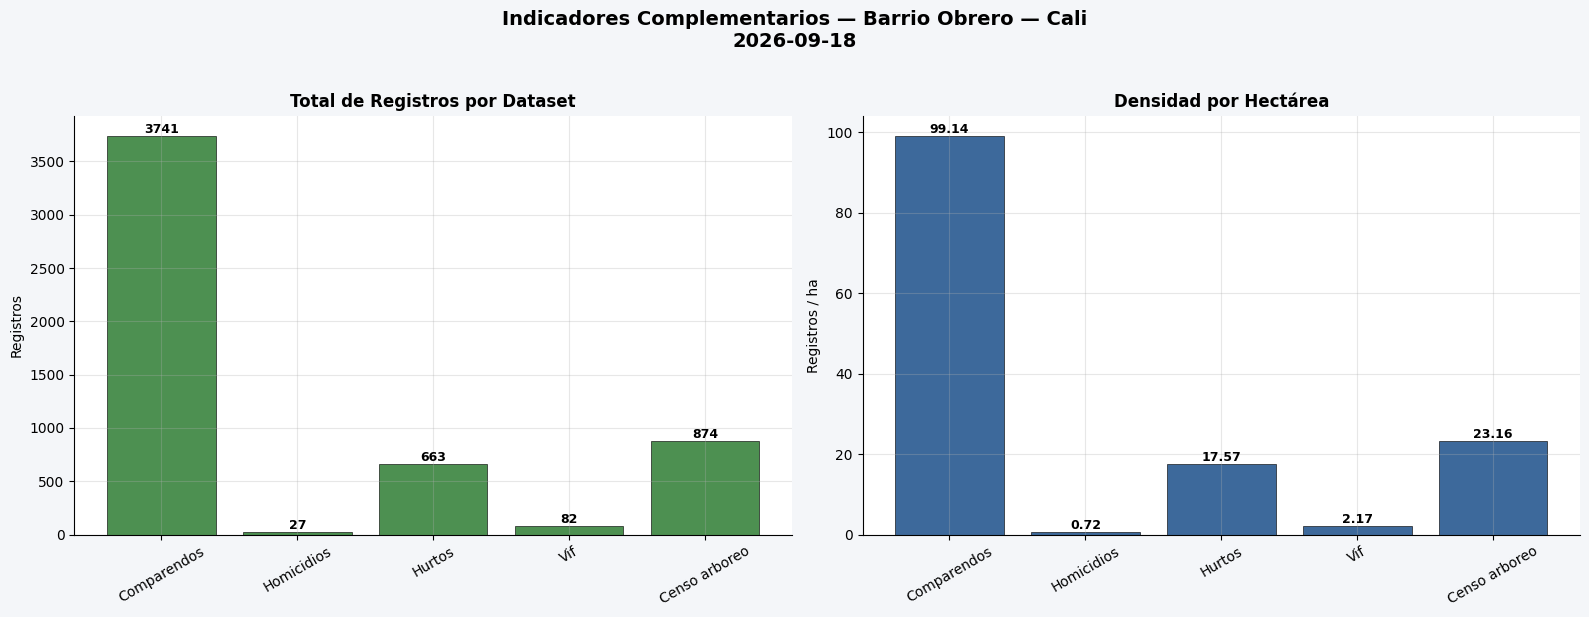

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\barrio_obrero_indicadores_complementarios.png


In [ ]:
# Gráfico de barras de indicadores complementarios
if indicadores:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    nombres = list(indicadores.keys())
    totales = [indicadores[n]['total'] for n in nombres]
    densidades = [indicadores[n]['densidad_por_ha'] for n in nombres]
    labels = [n.replace('_', ' ').capitalize() for n in nombres]

    bars0 = axes[0].bar(labels, totales, color='#2E7D32', alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[0].set_title('Total de Registros por Dataset', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Registros')
    axes[0].tick_params(axis='x', rotation=30)
    for b, v in zip(bars0, totales):
        axes[0].text(b.get_x()+b.get_width()/2, b.get_height(), f'{v}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    bars1 = axes[1].bar(labels, densidades, color='#1B4F8A', alpha=0.85, edgecolor='black', linewidth=0.5)
    axes[1].set_title('Densidad por Hectárea', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Registros / ha')
    axes[1].tick_params(axis='x', rotation=30)
    for b, v in zip(bars1, densidades):
        axes[1].text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.suptitle(f'Indicadores Complementarios — {ZONA_NOMBRE}\n{datetime.date.today().isoformat()}',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(IMG_DIR / 'barrio_obrero_indicadores_complementarios.png', dpi=200, bbox_inches='tight')
    plt.show()
    print(f'Exportado: {IMG_DIR / "barrio_obrero_indicadores_complementarios.png"}')
else:
    print('⚠ No hay indicadores para graficar')

## Celda 11 — Exportar resultados

In [ ]:
resultado = {
    'fecha_medicion': datetime.date.today().isoformat(),
    'poligono': 'Barrio Obrero',
    'crs_trabajo': CRS_WGS84,
    'crs_calculo': CRS_COLOMBIA,
    'area_m2': round(area_m2, 0),
    'area_ha': round(area_m2 / 10000, 2),
    'intersecciones_peatonales': stats['intersection_count'],
    'longitud_red_peatonal_km': round(longitud_total_km, 2),
    'longitud_promedio_segmento_m': round(stats['edge_length_avg'], 1),
    'densidad_calle_km_km2': round(densidad_km_km2, 2),
    'nodos_osm': len(G.nodes),
    'segmentos_osm': len(G.edges),
    'fuente': 'OpenStreetMap via OSMnx',
    'momento': 'linea_base_pre_intervencion',
}

# Agregar conteos complementarios
for nombre, vals in indicadores.items():
    resultado[f'total_{nombre}'] = vals['total']
    resultado[f'densidad_{nombre}_por_ha'] = vals['densidad_por_ha']

df_resultados = pd.DataFrame([resultado])
output_csv = RESULTS_DIR / 'barrio_obrero_caminabilidad_linea_base.csv'
df_resultados.to_csv(output_csv, index=False)
print(f'Resultados exportados: {output_csv}')
print()
print(df_resultados.T.to_string())

Resultados exportados: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\results\barrio_obrero_caminabilidad_linea_base.csv

                                                         0
fecha_medicion                                  2026-09-18
poligono                                     Barrio Obrero
crs_trabajo                                      EPSG:4326
crs_calculo                                      EPSG:3116
area_m2                                           377329.0
area_ha                                              37.73
intersecciones_peatonales                              233
longitud_red_peatonal_km                             26.93
longitud_promedio_segmento_m                          41.6
densidad_calle_km_km2                                71.38
nodos_osm                                              233
segmentos_osm                                          648
fuente                             OpenStreetMap via OSMnx
momento                    

---
# GRÁFICOS BASE — Línea Base de Caminabilidad

Los siguientes gráficos constituyen la caracterización espacial y topológica
del Barrio Obrero para evaluación de impacto de la intervención.

## Gráfico 1 — Mapa de red peatonal (alta resolución)

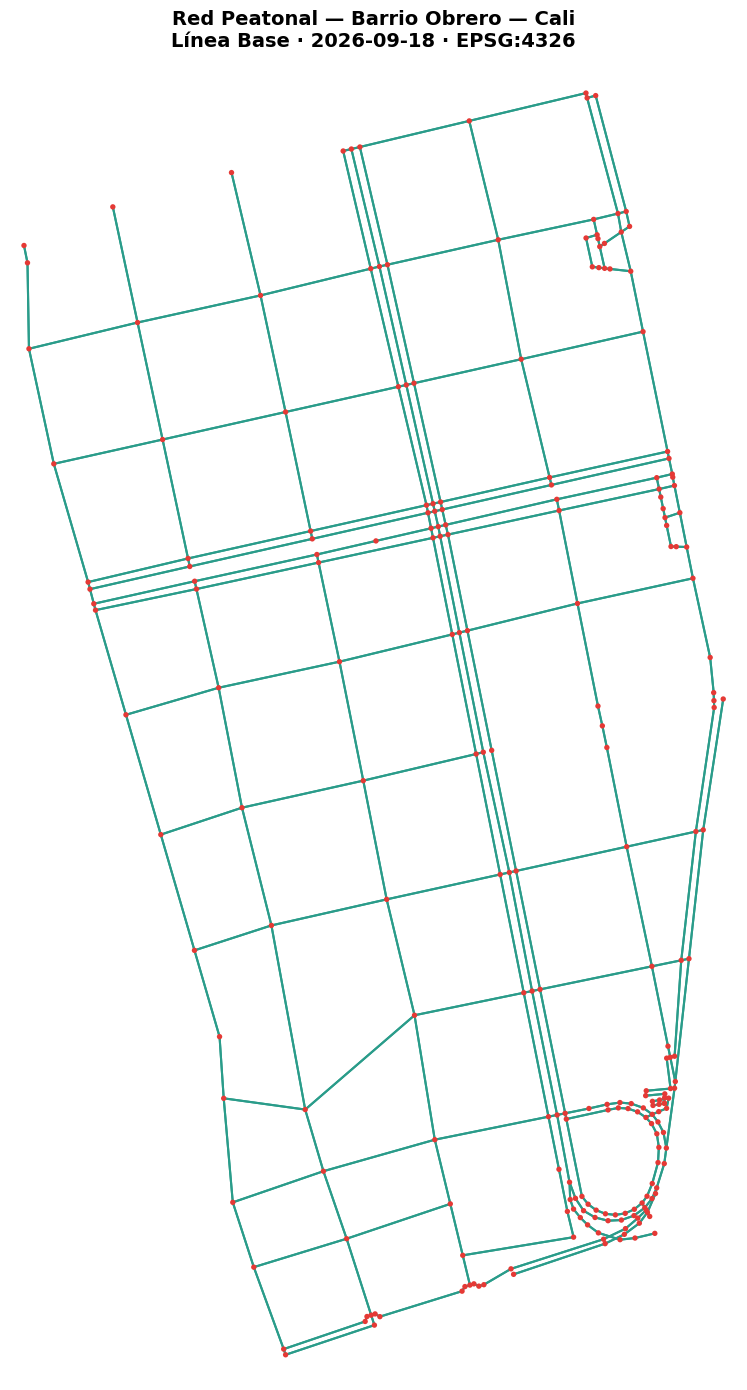

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_01_red_peatonal_barrio_obrero.png


In [ ]:
fig, ax = ox.plot_graph(
    G,
    node_size=15,
    node_color='#E53935',
    edge_linewidth=1.5,
    edge_color='#2A9C8A',
    bgcolor='white',
    figsize=(14, 14),
    show=False,
    close=False
)
ax.set_title(
    f'Red Peatonal — {ZONA_NOMBRE}\nLínea Base · {datetime.date.today().isoformat()} · {CRS_WGS84}',
    fontsize=14, pad=15, fontweight='bold'
)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_01_red_peatonal_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_01_red_peatonal_barrio_obrero.png"}')

## Gráfico 2 — Heatmap de densidad de intersecciones

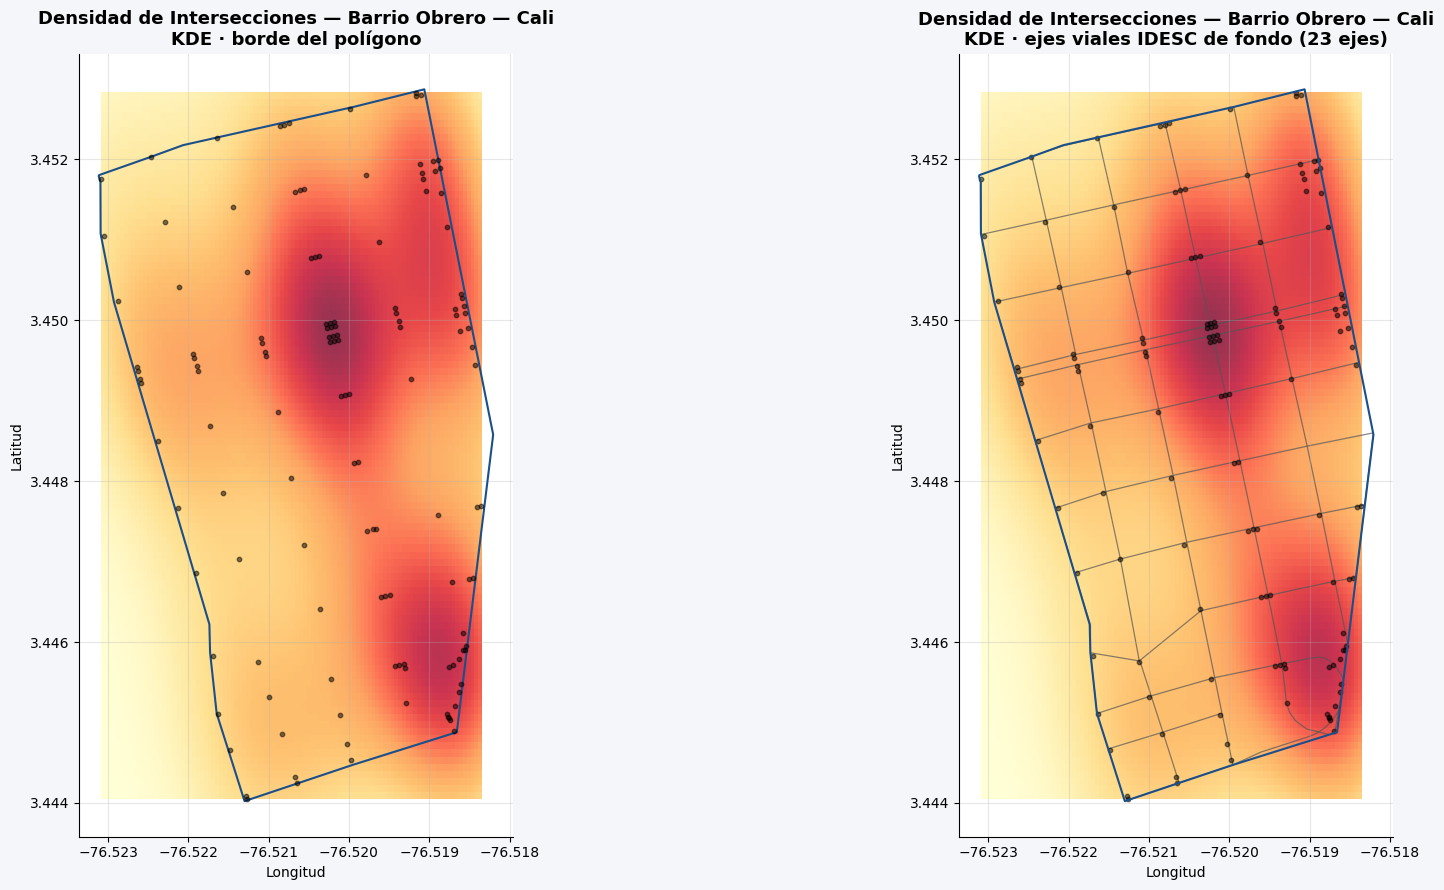

Intersecciones analizadas: 134
Ejes viales IDESC (recortados a la zona): 23
Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_02_heatmap_intersecciones_barrio_obrero.png


In [ ]:
from scipy.stats import gaussian_kde
# Obtener nodos que son intersecciones
gdf_nodes_all = ox.graph_to_gdfs(G, nodes=True, edges=False)
gdf_nodes_all = gdf_nodes_all.to_crs(CRS_WGS84)
if 'street_count' in gdf_nodes_all.columns:
    intersecciones = gdf_nodes_all[gdf_nodes_all['street_count'] > 2]
else:
    intersecciones = gdf_nodes_all
x = intersecciones.geometry.x.values
y = intersecciones.geometry.y.values

# --- Cargar malla vial IDESC recortada al polígono (para el 2do mapa) ---
def _cargar_vias_idesc():
    candidatos = [
        DATA_DIR / 'GeoJson_IDESC' / 'nomenclatura_vial.geojson',
        PROJECT_ROOT / 'data' / 'GeoJson_IDESC' / 'nomenclatura_vial.geojson',
    ]
    zips = [
        DATA_DIR / 'GeoJson_IDESC.zip',
        PROJECT_ROOT / 'data' / 'GeoJson_IDESC.zip',
    ]
    for c in candidatos:
        if c.exists():
            return gpd.read_file(c)
    for zp in zips:
        if zp.exists():
            return gpd.read_file(f'zip://{zp.as_posix()}!GeoJson_IDESC/nomenclatura_vial.geojson')
    return None

vias_idesc = _cargar_vias_idesc()
if vias_idesc is not None:
    if vias_idesc.crs is None:
        vias_idesc = vias_idesc.set_crs(CRS_WGS84)
    elif vias_idesc.crs.to_epsg() != 4326:
        vias_idesc = vias_idesc.to_crs(CRS_WGS84)
    vias_zona = gpd.clip(vias_idesc, gdf_poligono)
else:
    vias_zona = None

# Función auxiliar para dibujar el KDE en un eje dado
def _plot_kde(ax):
    if len(x) > 5:
        xy = np.vstack([x, y])
        kde = gaussian_kde(xy)
        xmin, xmax = x.min(), x.max()
        ymin, ymax = y.min(), y.max()
        xx, yy = np.mgrid[xmin:xmax:100j, ymin:ymax:100j]
        positions = np.vstack([xx.ravel(), yy.ravel()])
        density = kde(positions).reshape(xx.shape)
        ax.imshow(np.rot90(density), extent=[xmin, xmax, ymin, ymax],
                  cmap='YlOrRd', aspect='auto', alpha=0.8)
        ax.scatter(x, y, s=10, c='black', alpha=0.5, zorder=5)
    else:
        ax.scatter(x, y, s=30, c='red')

# === Figura con 2 paneles: (1) borde del polígono, (2) ejes viales IDESC de fondo ===
fig, axes = plt.subplots(1, 2, figsize=(20, 9))

# Panel 1 — heatmap con borde del polígono
_plot_kde(axes[0])
gdf_poligono.boundary.plot(ax=axes[0], color='#1B4F8A', linewidth=1.5)
axes[0].set_title(f'Densidad de Intersecciones — {ZONA_NOMBRE}\nKDE · borde del polígono',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Longitud'); axes[0].set_ylabel('Latitud')

# Panel 2 — heatmap con malla vial IDESC de fondo
if vias_zona is not None and len(vias_zona) > 0:
    vias_zona.plot(ax=axes[1], color='#555555', linewidth=0.9, alpha=0.7, zorder=1)
_plot_kde(axes[1])
gdf_poligono.boundary.plot(ax=axes[1], color='#1B4F8A', linewidth=1.5, zorder=6)
n_vias = len(vias_zona) if vias_zona is not None else 0
axes[1].set_title(f'Densidad de Intersecciones — {ZONA_NOMBRE}\nKDE · ejes viales IDESC de fondo ({n_vias} ejes)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Longitud'); axes[1].set_ylabel('Latitud')

plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_02_heatmap_intersecciones_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Intersecciones analizadas: {len(intersecciones)}')
print(f'Ejes viales IDESC (recortados a la zona): {n_vias}')
print(f'Exportado: {IMG_DIR / "graf_02_heatmap_intersecciones_barrio_obrero.png"}')

## Gráfico 3 — Histograma de longitud de segmentos

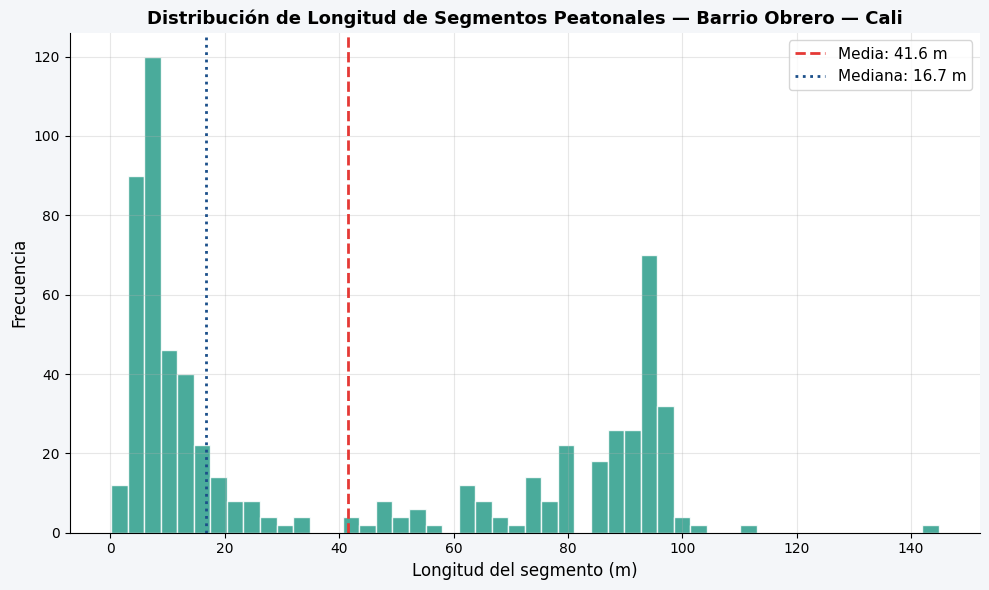

Segmentos: 648 | Media: 41.6m | Mediana: 16.7m
Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_03_histograma_segmentos_barrio_obrero.png


In [ ]:
gdf_edges_all = ox.graph_to_gdfs(G, nodes=False, edges=True)
longitudes = gdf_edges_all['length'].values

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(longitudes, bins=50, color='#2A9C8A', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(longitudes), color='#E53935', linestyle='--', linewidth=2,
           label=f'Media: {np.mean(longitudes):.1f} m')
ax.axvline(np.median(longitudes), color='#1B4F8A', linestyle=':', linewidth=2,
           label=f'Mediana: {np.median(longitudes):.1f} m')
ax.set_xlabel('Longitud del segmento (m)', fontsize=12)
ax.set_ylabel('Frecuencia', fontsize=12)
ax.set_title(f'Distribución de Longitud de Segmentos Peatonales — {ZONA_NOMBRE}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_03_histograma_segmentos_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Segmentos: {len(longitudes)} | Media: {np.mean(longitudes):.1f}m | Mediana: {np.median(longitudes):.1f}m')
print(f'Exportado: {IMG_DIR / "graf_03_histograma_segmentos_barrio_obrero.png"}')

## Gráfico 4 — Boxplot de segmentos peatonales

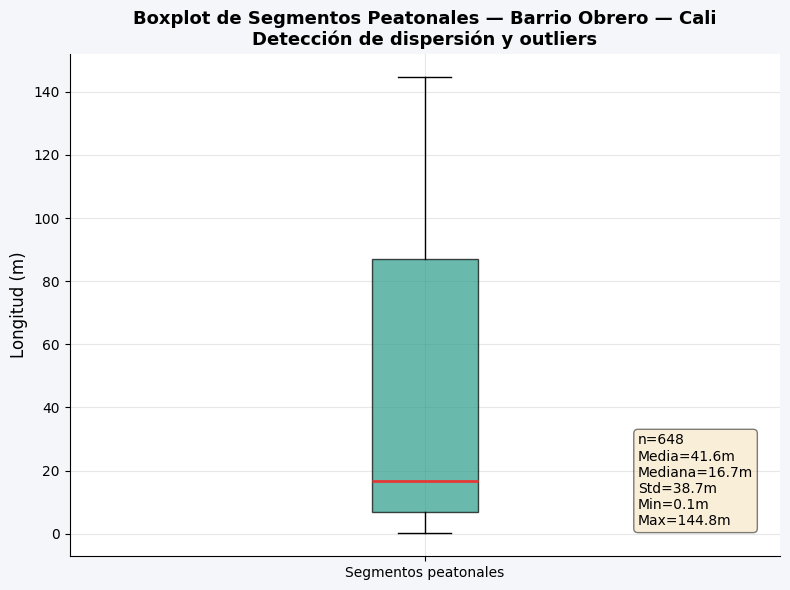

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_04_boxplot_segmentos_barrio_obrero.png


In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
bp = ax.boxplot(longitudes, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2A9C8A', alpha=0.7),
                medianprops=dict(color='#E53935', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#1B4F8A', markersize=4, alpha=0.5))
ax.set_ylabel('Longitud (m)', fontsize=12)
ax.set_title(f'Boxplot de Segmentos Peatonales — {ZONA_NOMBRE}\nDetección de dispersión y outliers',
             fontsize=13, fontweight='bold')
ax.set_xticklabels(['Segmentos peatonales'])
stats_text = (f'n={len(longitudes)}\n'
              f'Media={np.mean(longitudes):.1f}m\n'
              f'Mediana={np.median(longitudes):.1f}m\n'
              f'Std={np.std(longitudes):.1f}m\n'
              f'Min={np.min(longitudes):.1f}m\n'
              f'Max={np.max(longitudes):.1f}m')
ax.text(1.3, np.median(longitudes), stats_text, fontsize=10,
        verticalalignment='center', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_04_boxplot_segmentos_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_04_boxplot_segmentos_barrio_obrero.png"}')

## Gráfico 5 — Posición morfológica (conectividad)

Este gráfico ubica a Barrio Obrero según dos variables morfológicas de la red peatonal:
**longitud promedio de segmento (m)** y **densidad de intersecciones (int/km²)**. Para
saber si los valores tienen sentido, se comparan con referencias internacionales y nacionales.

### Valores de Barrio Obrero (línea base)

- Longitud promedio de segmento: **41.6 m**
- Densidad de intersecciones: **617 int/km²**
- (Comuna 9 de referencia: 34.8 m y 777 int/km²)

### Contexto internacional — densidad de intersecciones (int/km²)

| Referencia | Valor aprox. | Fuente |
|---|---|---|
| Umbral de salud pública (asociado a mayor actividad física) | ~100 int/km² | Estudio IPEN Adult / U. de Melbourne |
| Portland, OR (trama muy caminable) | ~1.500 int/mi² ≈ **580 int/km²** | US EPA EnviroAtlas |
| Los Ángeles, CA | ~150 int/mi² ≈ **58 int/km²** | US EPA EnviroAtlas |
| Irvine, CA (suburbano, cul-de-sac) | ~15 int/mi² ≈ **6 int/km²** | US EPA EnviroAtlas |

Lectura: en la literatura de caminabilidad, **~100 int/km²** es el umbral desde el cual una
zona empieza a considerarse favorable para caminar. Las tramas urbanas tradicionales tipo
retícula (grid) alcanzan varios cientos de int/km²; las tramas suburbanas de lazos y
cul-de-sac quedan muy por debajo. Con **617 int/km²**, Barrio Obrero está muy por encima del
umbral de salud pública y en el rango de tramas urbanas densas y caminables (comparable a
zonas centrales de ciudades como Portland).

### Contexto — longitud de cuadra / segmento

| Referencia | Valor | Fuente |
|---|---|---|
| Máxima recomendada para barrios caminables | ≤ 250 m | Regulación de "Walkable Neighbourhoods", Queensland (AU) |
| Mayor actividad peatonal en zonas comerciales | ~90–120 m (300–400 ft) | Estudios observacionales de diseño urbano |
| Umbral donde cae la actividad peatonal | > ~150 m (500 ft) | Estudios observacionales de diseño urbano |

Lectura: cuadras/segmentos cortos favorecen la caminabilidad (más rutas y cruces). La
longitud promedio de segmento de OSM (**41.6 m**) es menor que una cuadra completa porque
`simplify=False` divide cada calle en micro-tramos entre vértices; por eso conviene
interpretarla junto con la densidad de intersecciones, no de forma aislada. Aun así, indica
una malla fina y bien conectada, coherente con la alta densidad de intersecciones.

### Conclusión

Los valores de Barrio Obrero son consistentes con una **zona urbana consolidada y caminable**:
densidad de intersecciones muy por encima del umbral de salud pública (~100 int/km²) y una
malla peatonal fina. La Comuna 9, que lo contiene, es incluso algo más densa (777 int/km²),
lo que sitúa a Barrio Obrero como un barrio con buena conectividad dentro de un contexto
comunal favorable.

### Referencias

- US EPA — *Estimated Intersection Density of Walkable Roads* (EnviroAtlas):
  https://enviroatlas.epa.gov/enviroatlas/DataFactSheets/pdf/Supplemental/EstimatedIntersectionDensityOfWalkableRoads.pdf
- U. de Melbourne / IPEN Adult study — umbrales de diseño urbano para caminar (~100 int/km²):
  https://pursuit.unimelb.edu.au/articles/australian-cities-failing-on-walkability
- Arundel et al., *Determining thresholds for spatial urban design and transport features that support walking* (IPEN):
  https://research-repository.uwa.edu.au/en/publications/determining-thresholds-for-spatial-urban-design-and-transport-fea/
- Queensland Government — *Planning (Walkable Neighbourhoods) Amendment Regulation 2020* (cuadras ≤ 250 m):
  https://www.parliament.qld.gov.au/Work-of-the-Assembly/Tabled-Papers/docs/5620T1443/5620t1443.pdf
- Stangl, P. (2015), *Block size-based measures of street connectivity*, Urban Design International.

Nota: los umbrales provienen mayormente de literatura anglosajona (EE. UU. y Australia); no
existe un estándar nacional colombiano de densidad de intersecciones ampliamente adoptado, por
lo que aquí se usan como referencia comparativa y la Comuna 9 aporta el contraste local.
Contenido reformulado para cumplir con restricciones de licencia de las fuentes.

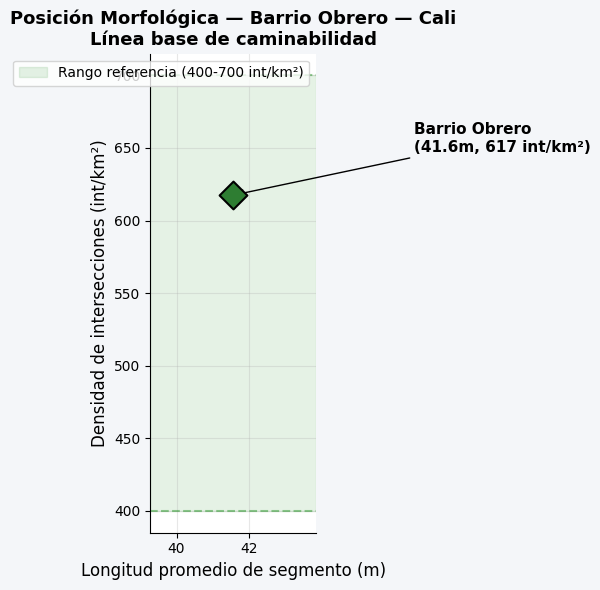

Longitud promedio: 41.6 m
Densidad intersecciones: 617 int/km²
Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_05_scatter_conectividad_barrio_obrero.png


In [ ]:
long_prom = np.mean(longitudes)
densidad_intersecciones = stats['intersection_count'] / area_km2

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(long_prom, densidad_intersecciones, s=200, c='#2E7D32', marker='D',
           edgecolors='black', linewidth=1.5, zorder=5)
ax.annotate(f'Barrio Obrero\n({long_prom:.1f}m, {densidad_intersecciones:.0f} int/km²)',
            xy=(long_prom, densidad_intersecciones),
            xytext=(long_prom + 5, densidad_intersecciones + 30),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))
ax.axhspan(400, 700, alpha=0.1, color='green', label='Rango referencia (400-700 int/km²)')
ax.axhline(400, color='green', linestyle='--', alpha=0.4)
ax.axhline(700, color='green', linestyle='--', alpha=0.4)
ax.set_xlabel('Longitud promedio de segmento (m)', fontsize=12)
ax.set_ylabel('Densidad de intersecciones (int/km²)', fontsize=12)
ax.set_title(f'Posición Morfológica — {ZONA_NOMBRE}\nLínea base de caminabilidad',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_05_scatter_conectividad_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Longitud promedio: {long_prom:.1f} m')
print(f'Densidad intersecciones: {densidad_intersecciones:.0f} int/km²')
print(f'Exportado: {IMG_DIR / "graf_05_scatter_conectividad_barrio_obrero.png"}')

## Gráfico 6 — Tabla resumen de métricas urbanas

=== TABLA RESUMEN — Barrio Obrero — Cali ===
Fecha: 2026-09-18 | CRS: EPSG:4326

                             Métrica    Valor
                     Área total (ha)  37.7300
                    Área total (km²)   0.3773
           Intersecciones peatonales 233.0000
          Longitud total de red (km)  26.9300
      Longitud promedio segmento (m)  41.6000
                Mediana segmento (m)  16.7000
          Densidad de calle (km/km²)  71.3800
Densidad de intersecciones (int/km²) 617.0000
                           Nodos OSM 233.0000
                       Segmentos OSM 648.0000

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\results\barrio_obrero_tabla_resumen_metricas.csv


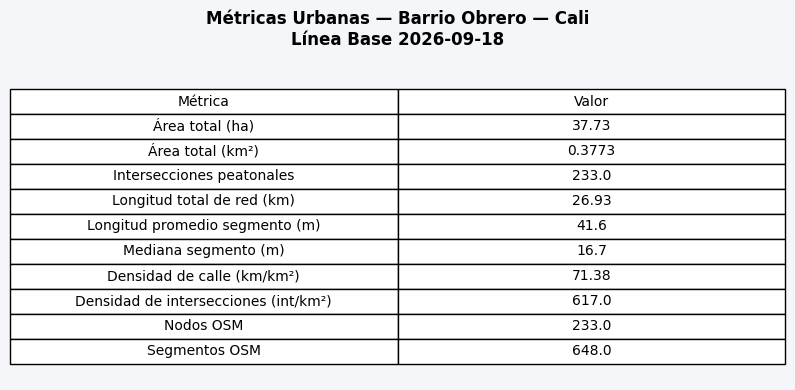

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_06_tabla_metricas_barrio_obrero.png


In [ ]:
densidad_intersecciones_km2 = stats['intersection_count'] / area_km2
tabla_resumen = pd.DataFrame({
    'Métrica': [
        'Área total (ha)',
        'Área total (km²)',
        'Intersecciones peatonales',
        'Longitud total de red (km)',
        'Longitud promedio segmento (m)',
        'Mediana segmento (m)',
        'Densidad de calle (km/km²)',
        'Densidad de intersecciones (int/km²)',
        'Nodos OSM',
        'Segmentos OSM',
    ],
    'Valor': [
        round(area_m2 / 10000, 2),
        round(area_km2, 4),
        stats['intersection_count'],
        round(longitud_total_km, 2),
        round(np.mean(longitudes), 1),
        round(np.median(longitudes), 1),
        round(densidad_km_km2, 2),
        round(densidad_intersecciones_km2, 0),
        len(G.nodes),
        len(G.edges),
    ]
})

print(f'=== TABLA RESUMEN — {ZONA_NOMBRE} ===')
print(f'Fecha: {datetime.date.today().isoformat()} | CRS: {CRS_WGS84}')
print()
print(tabla_resumen.to_string(index=False))

tabla_resumen.to_csv(RESULTS_DIR / 'barrio_obrero_tabla_resumen_metricas.csv', index=False)
print(f'\nExportado: {RESULTS_DIR / "barrio_obrero_tabla_resumen_metricas.csv"}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table = ax.table(cellText=tabla_resumen.values, colLabels=tabla_resumen.columns,
                 cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
ax.set_title(f'Métricas Urbanas — {ZONA_NOMBRE}\nLínea Base {datetime.date.today().isoformat()}',
             fontsize=12, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_06_tabla_metricas_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_06_tabla_metricas_barrio_obrero.png"}')

## Celda 14B — Gráfica de métricas de caminabilidad

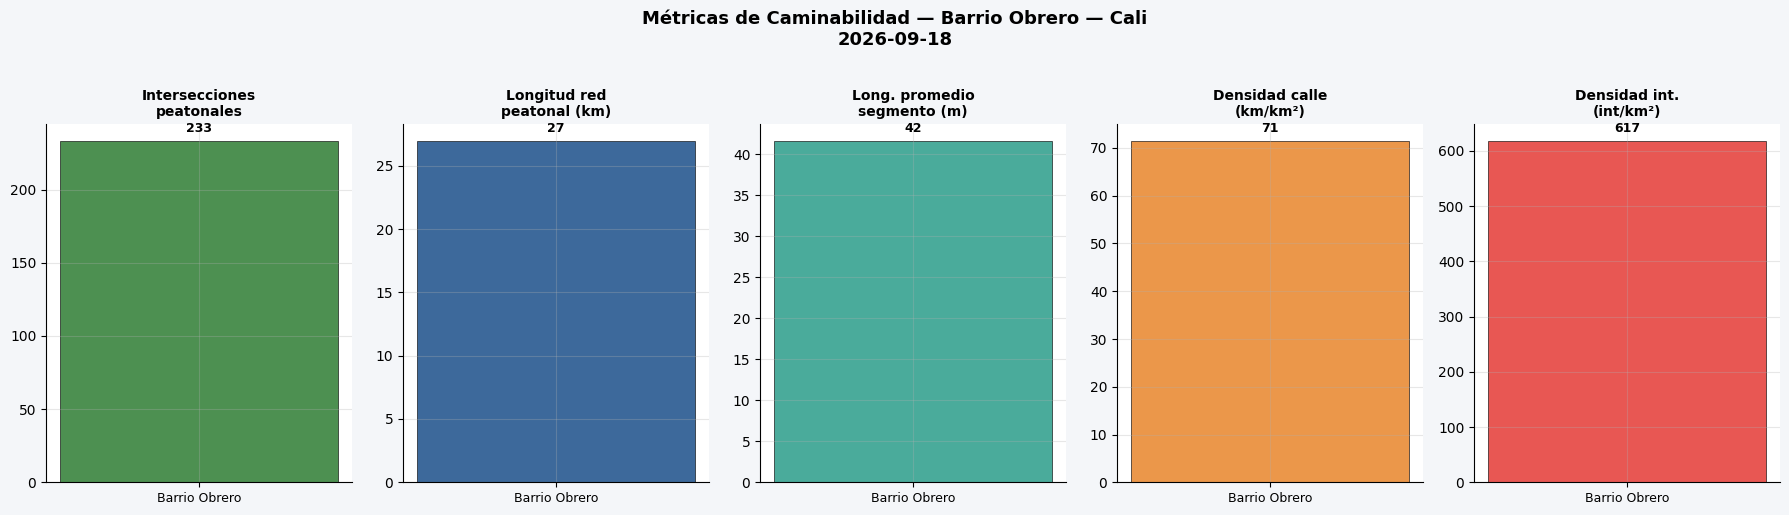

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_metricas_caminabilidad_barrio_obrero.png


In [ ]:
# Panel de métricas de caminabilidad — Barrio Obrero (zona única, sin espejo)
metricas_bo = {
    'intersecciones_peatonales': stats['intersection_count'],
    'longitud_red_peatonal_km': round(longitud_total_km, 2),
    'longitud_promedio_segmento_m': round(np.mean(longitudes), 1),
    'densidad_calle_km_km2': round(densidad_km_km2, 2),
    'densidad_intersecciones_km2': round(stats['intersection_count'] / area_km2, 0),
}
titulos_graf = ['Intersecciones\npeatonales', 'Longitud red\npeatonal (km)',
                'Long. promedio\nsegmento (m)', 'Densidad calle\n(km/km²)', 'Densidad int.\n(int/km²)']
metricas_graf = list(metricas_bo.keys())
colores_metrica = ['#2E7D32', '#1B4F8A', '#2A9C8A', '#E8852A', '#E53935']

fig, axes = plt.subplots(1, len(metricas_graf), figsize=(18, 5))
for i, (metrica, titulo) in enumerate(zip(metricas_graf, titulos_graf)):
    ax = axes[i]
    val = metricas_bo[metrica]
    bar = ax.bar(['Barrio Obrero'], [val], color=colores_metrica[i], alpha=0.85,
                 edgecolor='black', linewidth=0.5)
    ax.set_title(titulo, fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', labelsize=9)
    ax.text(bar[0].get_x() + bar[0].get_width() / 2, val + val * 0.02,
            f'{val:.0f}' if val > 10 else f'{val:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'Métricas de Caminabilidad — {ZONA_NOMBRE}\n{datetime.date.today().isoformat()}',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(IMG_DIR / 'graf_metricas_caminabilidad_barrio_obrero.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Exportado: {IMG_DIR / "graf_metricas_caminabilidad_barrio_obrero.png"}')

## Celda 14C — Comparación Barrio Obrero vs Comuna 9

Comuna 9 — área: 2,903,826 m² (290.38 ha)
Descargando red peatonal OSM de la Comuna 9 (simplify=False)...


  Nodos: 2288 | Segmentos: 6536

=== COMPARACIÓN Barrio Obrero vs Comuna 9 ===
               area_ha  intersecciones_peatonales  longitud_red_peatonal_km  longitud_promedio_segmento_m  densidad_calle_km_km2  densidad_intersecciones_km2
zona                                                                                                                                                         
Barrio Obrero    37.73                      233.0                     26.93                          41.6                  71.38                        617.0
Comuna 9        290.38                     2255.0                    227.52                          34.8                  78.35                        777.0

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\results\comparacion_barrio_obrero_vs_comuna9.csv


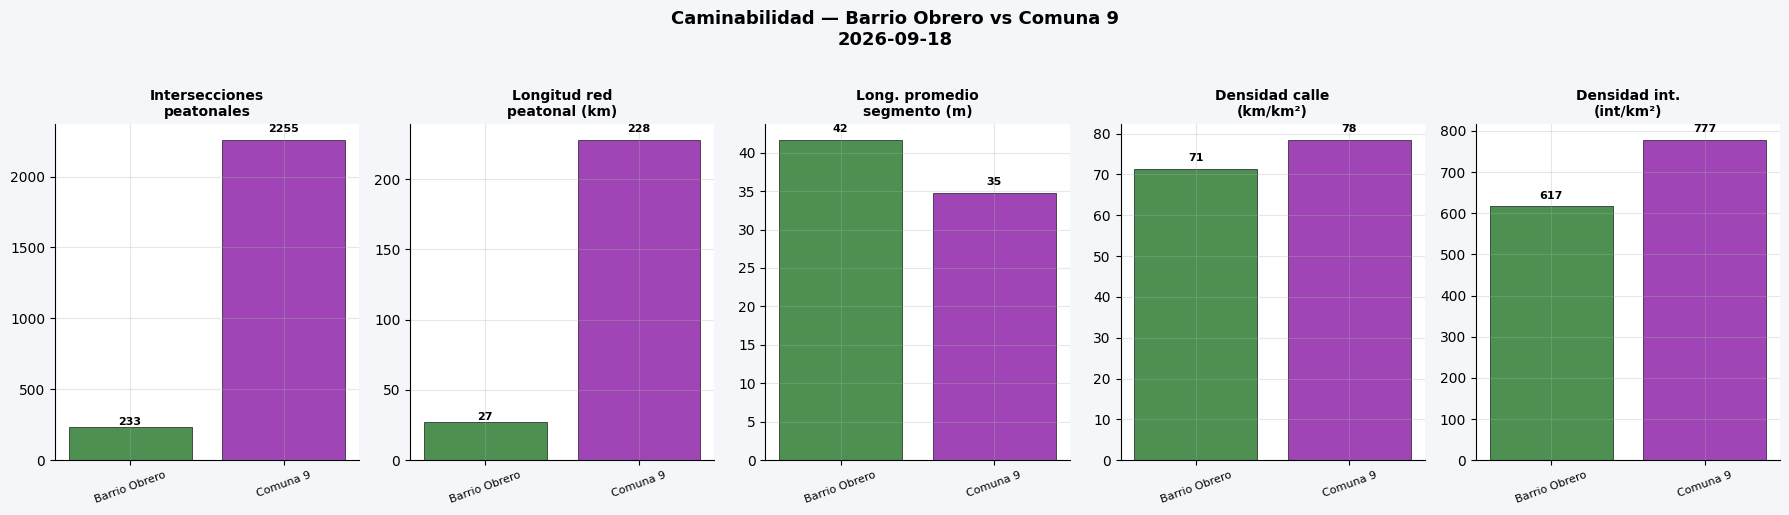

Exportado: C:\Users\Jorge\Documents\GOBIERNO_DE_DATOS\Indice_Caminabilidad\outputs\figures\graf_comparacion_barrio_obrero_vs_comuna9.png


In [ ]:
# Comparación de caminabilidad: Barrio Obrero vs Comuna 9 (contexto territorial)
# Barrio Obrero está dentro de la Comuna 9. Se descarga la red peatonal OSM de la
# comuna completa y se comparan las mismas métricas de caminabilidad.

# --- Cargar polígono de la Comuna 9 desde IDESC (carpeta o ZIP) ---
def _cargar_comunas_idesc():
    candidatos = [
        DATA_DIR / 'GeoJson_IDESC' / 'comunas.geojson',
        PROJECT_ROOT / 'data' / 'GeoJson_IDESC' / 'comunas.geojson',
    ]
    zips = [
        DATA_DIR / 'GeoJson_IDESC.zip',
        PROJECT_ROOT / 'data' / 'GeoJson_IDESC.zip',
    ]
    for c in candidatos:
        if c.exists():
            return gpd.read_file(c)
    for zp in zips:
        if zp.exists():
            return gpd.read_file(f'zip://{zp.as_posix()}!GeoJson_IDESC/comunas.geojson')
    return None

comunas = _cargar_comunas_idesc()
if comunas is None:
    print('⚠ No se encontró comunas.geojson (IDESC); se omite la comparación.')
else:
    if comunas.crs is None:
        comunas = comunas.set_crs(CRS_WGS84)
    elif comunas.crs.to_epsg() != 4326:
        comunas = comunas.to_crs(CRS_WGS84)
    gdf_c9 = comunas[comunas['comuna'].astype(str) == '9']
    if len(gdf_c9) == 0:
        print('⚠ Comuna 9 no encontrada en comunas.geojson.')
    else:
        polygon_c9 = gdf_c9.geometry.iloc[0]
        area_c9_m2 = gdf_c9.to_crs(CRS_COLOMBIA).geometry.area.iloc[0]
        area_c9_km2 = area_c9_m2 / 1_000_000
        print(f'Comuna 9 — área: {area_c9_m2:,.0f} m² ({area_c9_m2/10000:.2f} ha)')
        print('Descargando red peatonal OSM de la Comuna 9 (simplify=False)...')
        G_c9 = ox.graph_from_polygon(polygon_c9, network_type='walk', simplify=False)
        stats_c9 = ox.basic_stats(G_c9, area=area_c9_m2)
        edges_c9 = ox.graph_to_gdfs(G_c9, nodes=False, edges=True)
        long_c9 = edges_c9['length'].values
        long_total_c9_km = stats_c9['edge_length_total'] / 1000
        print(f'  Nodos: {len(G_c9.nodes)} | Segmentos: {len(G_c9.edges)}')

        # Métricas comparables
        metricas_zonas = {
            'Barrio Obrero': {
                'area_ha': round(area_m2 / 10000, 2),
                'intersecciones_peatonales': stats['intersection_count'],
                'longitud_red_peatonal_km': round(longitud_total_km, 2),
                'longitud_promedio_segmento_m': round(np.mean(longitudes), 1),
                'densidad_calle_km_km2': round(densidad_km_km2, 2),
                'densidad_intersecciones_km2': round(stats['intersection_count'] / area_km2, 0),
            },
            'Comuna 9': {
                'area_ha': round(area_c9_m2 / 10000, 2),
                'intersecciones_peatonales': stats_c9['intersection_count'],
                'longitud_red_peatonal_km': round(long_total_c9_km, 2),
                'longitud_promedio_segmento_m': round(np.mean(long_c9), 1),
                'densidad_calle_km_km2': round(long_total_c9_km / area_c9_km2, 2),
                'densidad_intersecciones_km2': round(stats_c9['intersection_count'] / area_c9_km2, 0),
            },
        }
        df_comp_c9 = pd.DataFrame(metricas_zonas).T
        df_comp_c9.index.name = 'zona'
        print()
        print('=== COMPARACIÓN Barrio Obrero vs Comuna 9 ===')
        print(df_comp_c9.to_string())

        # Exportar CSV comparativo
        out_csv = RESULTS_DIR / 'comparacion_barrio_obrero_vs_comuna9.csv'
        df_comp_c9.reset_index().to_csv(out_csv, index=False)
        print(f'\nExportado: {out_csv}')

        # Gráfica comparativa (5 métricas de caminabilidad; se omite area_ha)
        metricas_graf = ['intersecciones_peatonales', 'longitud_red_peatonal_km',
                         'longitud_promedio_segmento_m', 'densidad_calle_km_km2',
                         'densidad_intersecciones_km2']
        titulos_graf = ['Intersecciones\npeatonales', 'Longitud red\npeatonal (km)',
                        'Long. promedio\nsegmento (m)', 'Densidad calle\n(km/km²)',
                        'Densidad int.\n(int/km²)']
        colores_zona = {'Barrio Obrero': '#2E7D32', 'Comuna 9': '#8E24AA'}
        zonas = list(metricas_zonas.keys())
        fig, axes = plt.subplots(1, len(metricas_graf), figsize=(18, 5))
        for i, (metrica, titulo) in enumerate(zip(metricas_graf, titulos_graf)):
            ax = axes[i]
            valores = [metricas_zonas[z][metrica] for z in zonas]
            colors = [colores_zona[z] for z in zonas]
            bars = ax.bar(zonas, valores, color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)
            ax.set_title(titulo, fontsize=10, fontweight='bold')
            ax.tick_params(axis='x', rotation=20, labelsize=8)
            for bar, val in zip(bars, valores):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + bar.get_height()*0.02,
                        f'{val:.0f}' if val > 10 else f'{val:.1f}',
                        ha='center', va='bottom', fontsize=8, fontweight='bold')
        plt.suptitle(f'Caminabilidad — Barrio Obrero vs Comuna 9\n{datetime.date.today().isoformat()}',
                     fontsize=13, fontweight='bold', y=1.02)
        plt.tight_layout()
        plt.savefig(IMG_DIR / 'graf_comparacion_barrio_obrero_vs_comuna9.png', dpi=200, bbox_inches='tight')
        plt.show()
        print(f'Exportado: {IMG_DIR / "graf_comparacion_barrio_obrero_vs_comuna9.png"}')